<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/Mia/03b_visualizations_businesstype_RDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install contextily

In [17]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [20]:
df = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_rde_cleaned.csv')

In [21]:
df['location_start_date'] = pd.to_datetime(df['location_start_date'], errors='coerce')
df['location_end_date'] = pd.to_datetime(df['location_end_date'], errors='coerce')

#creating two dataframes to represent businesses opening/closing within our timeframe (businesses opening 2016 onwards and businesses closing pre-2026)

df_filtered_start = df[
    (df['location_start_date'] >= '2016-01-01') &
    (df['location_start_date'] < '2026-01-01')
]
df_filtered_end = df[
    (df['location_end_date'] < '2026-01-01') &
    (df['location_end_date'] >= '2016-01-01')
]

In [22]:
#converting values to datetime and creating a new column for the necessary year
df_filtered_start['location_start_date'] = pd.to_datetime(df_filtered_start['location_start_date'], errors='coerce')
df_filtered_end['location_end_date'] = pd.to_datetime(df_filtered_end['location_end_date'], errors='coerce')

df_filtered_start['open_year'] = df_filtered_start['location_start_date'].dt.year
df_filtered_end['close_year'] = df_filtered_end['location_end_date'].dt.year

/tmp/ipykernel_37492/3839720111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_start['location_start_date'] = pd.to_datetime(df_filtered_start['location_start_date'], errors='coerce')
/tmp/ipykernel_37492/3839720111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_end['location_end_date'] = pd.to_datetime(df_filtered_end['location_end_date'], errors='coerce')
/tmp/ipykernel_37492/3839720111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

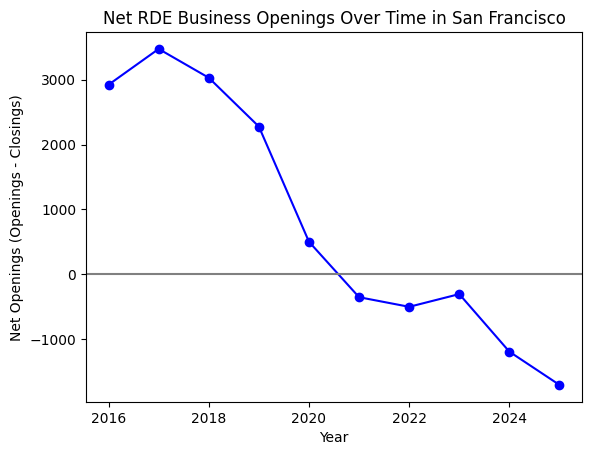

In [23]:
# Counting openings and closings by year
openings = df_filtered_start.groupby('open_year').size()
closings = df_filtered_end.groupby('close_year').size()

# Combining into one dataframe
net = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Calculating net change
net['net_openings'] = net['openings'] - net['closings']

# Sorting by year
net = net.sort_index()

plt.figure()
plt.plot(net.index, net['net_openings'], marker='o', color='blue')
plt.xlabel('Year')
plt.ylabel('Net Openings (Openings - Closings)')
plt.title('Net RDE Business Openings Over Time in San Francisco')
plt.axhline(0, color='gray')
plt.show()

/tmp/ipykernel_37492/1593795923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')


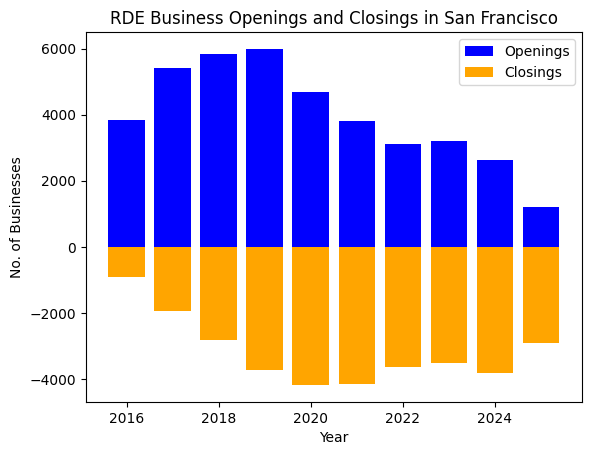

In [24]:

df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')

# Combining openings and closings
bars = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

# Making closings negative
bars['closings'] = -bars['closings']

# Sorting by year
bars = bars.sort_index()

plt.figure()
plt.bar(bars.index, bars['openings'], label='Openings', color='blue')
plt.bar(bars.index, bars['closings'], label='Closings', color='orange')
plt.xlabel('Year')
plt.ylabel('No. of Businesses')
plt.title('RDE Business Openings and Closings in San Francisco')
plt.legend()
plt.show()

In [25]:
#sanity checking values

openings = df_filtered_start.groupby('open_year').size()
openings

,0
open_year,
2016,3848
2017,5421
2018,5839
2019,5989
2020,4679
2021,3806
2022,3125
2023,3204
2024,2629


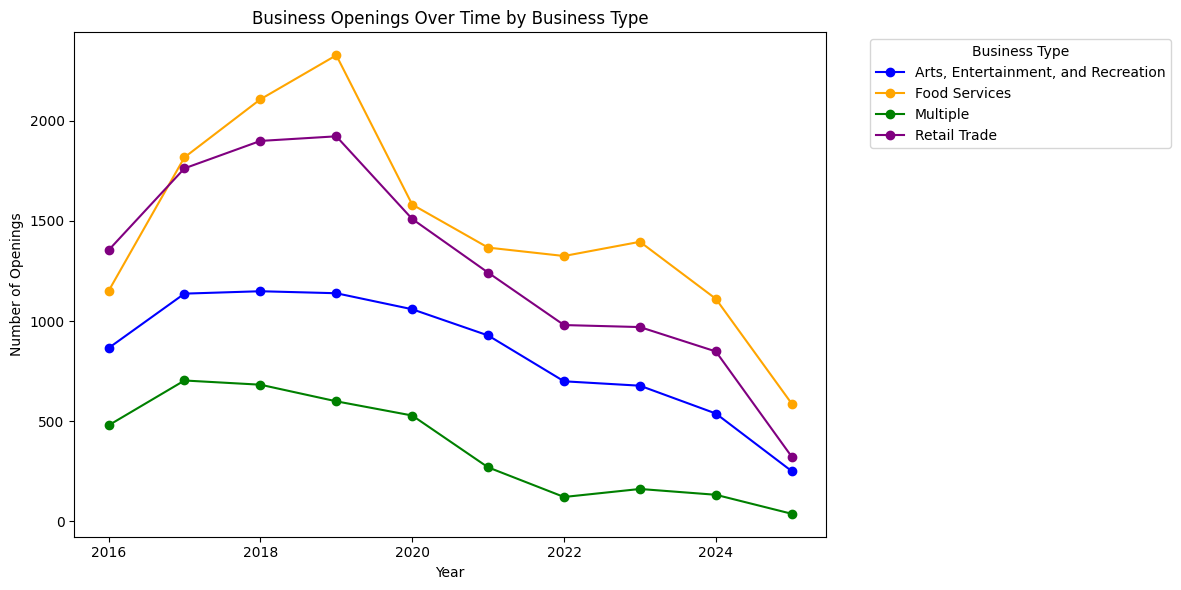

In [26]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type = df_filtered_start.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type = openings_by_type[openings_by_type.index < 2026]

colors = ['blue', 'orange', 'green', 'purple']

plt.figure(figsize=(12, 6))

for i, business_type in enumerate(openings_by_type.columns):
    plt.plot(
        openings_by_type.index,
        openings_by_type[business_type],
        marker='o',
        label=business_type,
        color=colors[i % len(colors)]
    )
plt.title('Business Openings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Openings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

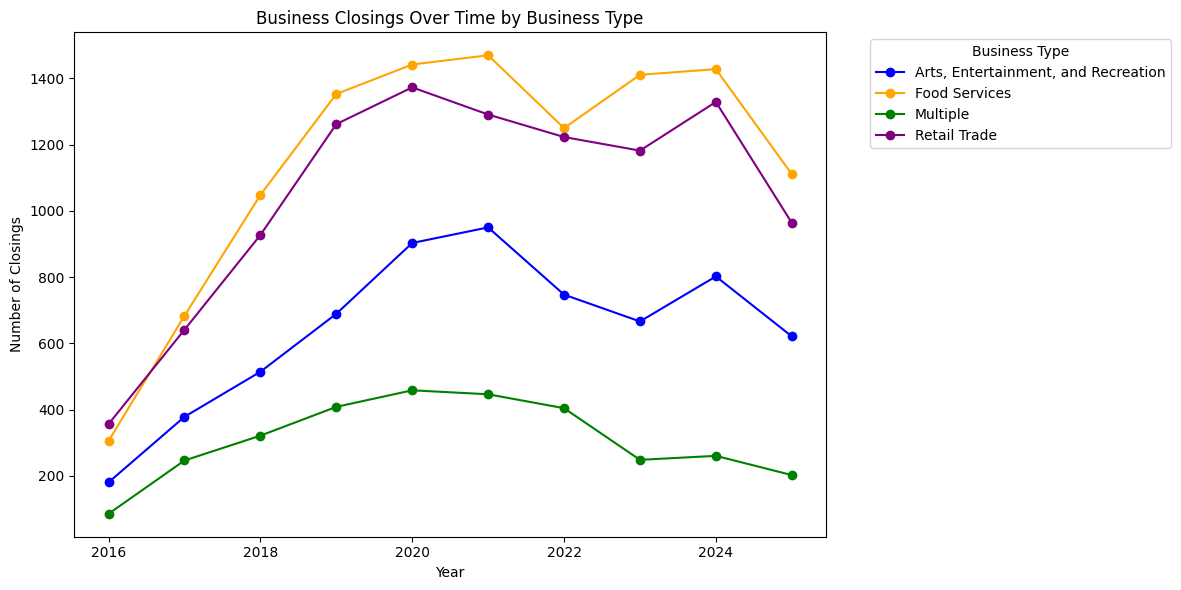

In [27]:
#Same thing for business closings
#Set up naics code descriptions to print and remove errant 2026 values
closings_by_type = df_filtered_end.groupby(['close_year', 'naics_code_description']).size().unstack(fill_value=0)
closings_by_type = closings_by_type[closings_by_type.index < 2026]

plt.figure(figsize=(12, 6))

for i, business_type in enumerate(closings_by_type.columns):
    plt.plot(
        closings_by_type.index,
        closings_by_type[business_type],
        marker='o',
        label=business_type,
        color=colors[i % len(colors)]
    )

plt.title('Business Closings Over Time by Business Type')
plt.xlabel('Year')
plt.ylabel('Number of Closings')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
# Combine openings and closings again (if needed)
pct_df = pd.DataFrame({
    'openings': openings,
    'closings': closings
}).fillna(0)

pct_df = pct_df.sort_index()

# Keep only 2016–2025 just to be safe
pct_df = pct_df[(pct_df.index >= 2016) & (pct_df.index < 2026)]

In [30]:
baseline_open = pct_df.loc[2016, 'openings']
baseline_close = pct_df.loc[2016, 'closings']

pct_df['openings_pct_change'] = ((pct_df['openings'] - baseline_open) / baseline_open) * 100
pct_df['closings_pct_change'] = ((pct_df['closings'] - baseline_close) / baseline_close) * 100

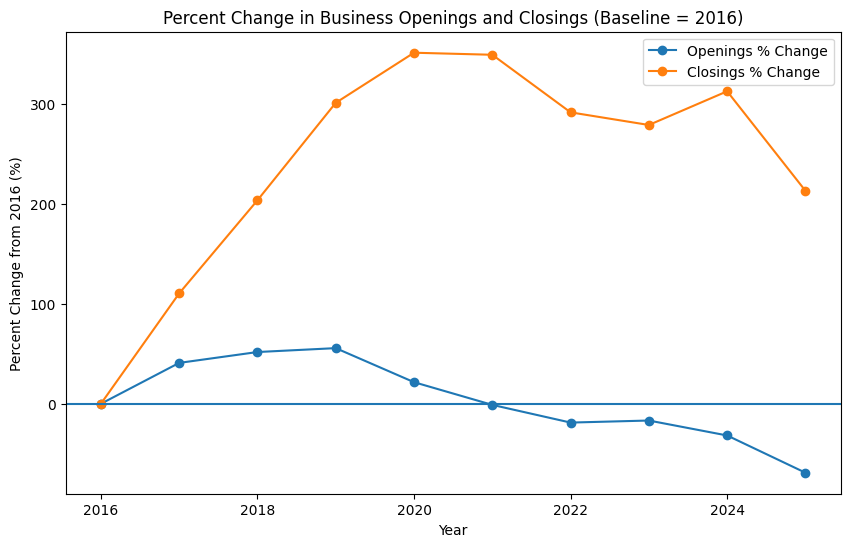

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

plt.axhline(0)  # baseline reference
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('Percent Change in Business Openings and Closings (Baseline = 2016)')
plt.legend()
plt.show()

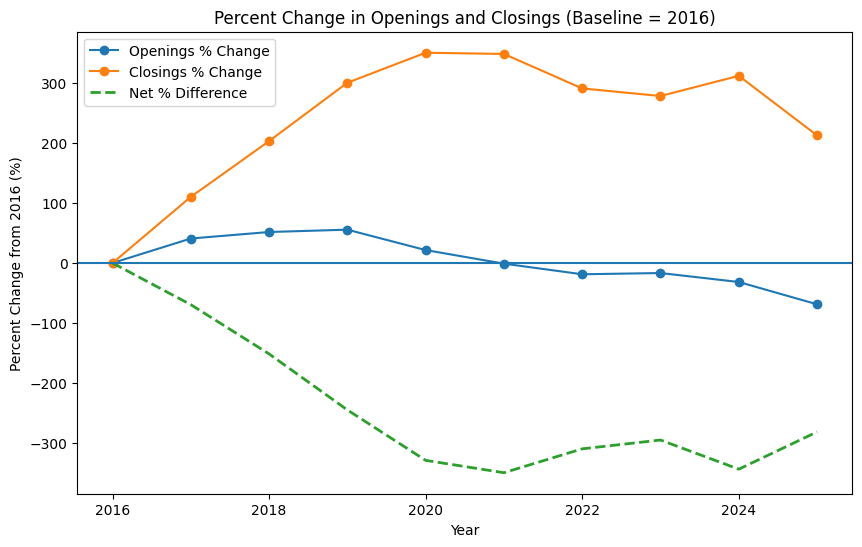

In [34]:
plt.figure(figsize=(10, 6))

# Plot percent changes
plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# Net difference in percent change
pct_df['net_pct_diff'] = pct_df['openings_pct_change'] - pct_df['closings_pct_change']

plt.plot(pct_df.index, pct_df['net_pct_diff'], linestyle='--', linewidth=2, label='Net % Difference')

plt.axhline(0)
plt.xlabel('Year')
plt.ylabel('Percent Change from 2016 (%)')
plt.title('Percent Change in Openings and Closings (Baseline = 2016)')
plt.legend()

plt.show()